<img src='sharif_logo.png' alt="SUT logo" width=150 height=150 align=left class="saturate" >

<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
 Deep Learning <br>
<font color=2565AE size=5>
Computer Engineering Department - Spring 2025  <br>
<font color=3C99D size=5>
          Homework 3: Practical - Oil Price Forecasting
 <br>
<font color=696880 size=4>
            Designer: Mohammad Amanlou
    
    

# 🛢️ Oil Price Prediction using Time Series Models 📈

This notebook is designed for students to complete tasks related to oil price prediction using different machine learning models. 🚀

## 📚 References
- 📊 [Dataset: Yahoo Finance - CL=F](https://finance.yahoo.com/quote/CL=F/history/)
- 📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)

## 1️⃣ Introduction
🔍 One of the most common applications of recurrent neural networks is **time series forecasting**. In this assignment, you will predict **crude oil prices** using four different methods. 💡

## 2️⃣ Dataset and Preprocessing (25 Points)

### 📥 2.1 Download Dataset
📌 Download the dataset from **Yahoo Finance** for `CL=F` from **2010 to the present**.
[Yahoo Finance - CL=F](https://finance.yahoo.com/quote/CL=F/history/)

### 🎯 2.2 Select Features
✅ Select the `Close` column as the **main feature**.

### ⚠️ **2.3 Handle Missing Data**

You will encounter missing data (`null` values) within your dataset. Follow these detailed steps carefully to handle the missing values and create a complete, reliable dataset:

#### 📝 Step 1: Introduce Random Missing Data
- Identify all indices in the `Close` column that currently have valid (non-null) data.
- Set a random seed (`np.random.seed(42)`) for reproducibility.
- Randomly select **10%** of these valid indices and set their values to `NaN`.

#### 🔍 Step 2: Identify Missing Values
- Identify all dates where at least one column has a missing value (`NaN`).
- Print the number of missing dates and the total number of dates to evaluate the extent of missingness.

#### 🔧 Step 3: Replace Missing Values
- Create a copy of the `Close` column for filling purposes.
- First, apply **linear interpolation** to estimate missing values based on surrounding data points.
- Then, use backward fill (`bfill`) followed by forward fill (`ffill`) methods to handle any remaining missing values at the start or end of the dataset.

#### 🎯 Outcome:
After completing these steps, your dataset will have no missing values in the `Close` column, ready for further analysis or modeling.

🛠 *Your task:* Implement the missing data handling methods below. (16 Points)

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf

# -------------------------------
# 📥 Download dataset (CL=F Crude Oil Futures)
# -------------------------------
df = yf.download("CL=F", start="2010-01-01")
df = df.reset_index()

# Select Close column only
df = df[["Date", "Close"]]
df.head()

/tmp/ipykernel_134/2847637096.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("CL=F", start="2010-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close
Ticker,,CL=F
0,2010-01-04,81.510002
1,2010-01-05,81.769997
2,2010-01-06,83.180000
3,2010-01-07,82.660004
4,2010-01-08,82.750000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3958 entries, 0 to 3957
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   (Date, )       3958 non-null   datetime64[ns]
 1   (Close, CL=F)  3958 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 62.0 KB


### ✂️ 2.4 Train-Test Split and Normalization
- **Split** the dataset into **training and test sets** based on the ratio given in the reference paper.
- **Normalize** the data.

📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)

🛠 *Your task:* Implement the splitting and normalization below. (4 Points)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


def temporal_split(series, train_ratio=0.6, val_ratio=0.2):
    """
    Splits a time series into train, validation, and test parts.
    series: pd.DataFrame with ['Date', 'Adj Close']
    """
    n = len(series)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    train = series.iloc[:train_end].copy()
    val = series.iloc[train_end:val_end].copy()
    test = series.iloc[val_end:].copy()

    return train, val, test


train_list, val_list, test_list = [], [], []

train, val, test = temporal_split(df)
train_list.append(train)
val_list.append(val)
test_list.append(test)

train_data = pd.concat(train_list)
val_data = pd.concat(val_list)
test_data = pd.concat(test_list)


scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
val_data['Close'] = scaler.transform(val_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])
print("Training data sample:")
display(train_data.head())
print("Validation data sample:")
display(val_data.head())
print("Testing data sample:")
display(test_data.head())

Training data sample:


Price,Date,Close
Ticker,,CL=F
0,2010-01-04,0.630415
1,2010-01-05,0.633379
2,2010-01-06,0.649453
3,2010-01-07,0.643525
4,2010-01-08,0.644551


Validation data sample:


Price,Date,Close
Ticker,,CL=F
2374,2019-06-13,0.297196
2375,2019-06-14,0.299818
2376,2019-06-17,0.293206
2377,2019-06-18,0.315663
2378,2019-06-19,0.314067


Testing data sample:


Price,Date,Close
Ticker,,CL=F
3165,2022-08-03,0.734724
3166,2022-08-04,0.710556
3167,2022-08-05,0.715914
3168,2022-08-08,0.735864
3169,2022-08-09,0.732900


### 📊 2.5 Data Visualization
- **Plot a histogram** similar to **Figure 6** in the reference paper, showing the **distribution of oil prices**.

🛠 *Your task:* Implement the histogram plot below. (5 Points)

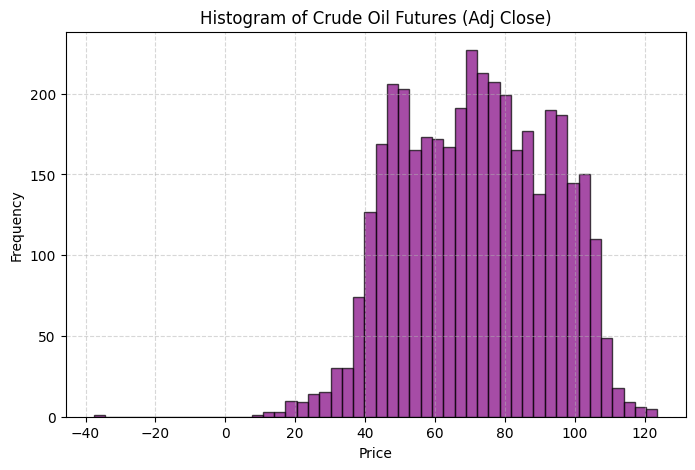

In [5]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
plt.hist(df["Close"], bins=50, alpha=0.7,color='purple', edgecolor="black")
plt.title("Histogram of Crude Oil Futures (Adj Close)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## 3️⃣ Implementing Deep Learning Models 🤖 (60 Points)

The reference paper utilizes **three models** for time series forecasting:
- `RNN`
- `LSTM`
- `GRU`

📌 **Train** each model using the **hyperparameters** given in **Table 4** of the paper.
📌 Use `Mean Square Error (MSE)` as the **loss function**.

📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)


### Important Details & Clarifications

- **What to Predict?**  
  The goal is to predict **the actual next-day price** (regression problem), rather than just identifying price increase or decrease.
  
- **Input/Output Structure:**  
  - **Input:** A window of \( k \) consecutive daily prices (e.g., 50 days).  
  - **Output:** The predicted price for the next day.
  
- **How to Evaluate?**  
  Use the four metrics (RMSE, MAE, MAPE, \( R^2 \)) to gauge how accurately your model tracks the real price values.

- **Target Accuracy:**  
  Your accuracy might differ from the paper’s due to factors like data splitting, normalization, or different random seeds. However, aim to closely replicate the paper’s results or provide justifications for any discrepancy.

**Final Deliverables:**
1. **All four trained models** (RNN, LSTM, GRU).  
2. **Comparison plots** of predicted vs. actual values (in both normalized and original price scales, if desired).  
3. **Performance metrics** (RMSE, MAE, MAPE, \( R^2 \)) for each model, presented in a table or a concise summary.


🛠 *Your task:* Implement these models below. (30 Points)

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# -------------------------------
# Create windowed sequences
# -------------------------------
def create_sequences(data, window_size):
    """
    Convert a 1D array of values into sequences for supervised learning.
    Input:
        data: numpy array or list of shape (n_samples,)
        window_size: number of timesteps in each input sequence
    Output:
        X: shape (n_sequences, window_size)
        y: shape (n_sequences,)
    """
    xs, ys = [], []
    for i in range(len(data) - window_size):
        x = data[i:(i + window_size)]
        y = data[i + window_size]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.float32)

# -------------------------------
# Parameters
# -------------------------------
window_size = 50
batch_size = 64  # from reference paper, adjust if needed

# -------------------------------
# Create sequences for each split
# -------------------------------
train_X, train_y = create_sequences(train_data['Close'].values, window_size)
val_X, val_y     = create_sequences(val_data['Close'].values, window_size)
test_X, test_y   = create_sequences(test_data['Close'].values, window_size)

# -------------------------------
# Wrap into Datasets & DataLoaders
# -------------------------------
train_dataset = TensorDataset(train_X, train_y)
val_dataset   = TensorDataset(val_X, val_y)
test_dataset  = TensorDataset(test_X, test_y)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print("✅ Data prepared:")
print(f"Train: {len(train_dataset)} sequences")
print(f"Val:   {len(val_dataset)} sequences")
print(f"Test:  {len(test_dataset)} sequences")


✅ Data prepared:
Train: 2324 sequences
Val:   741 sequences
Test:  743 sequences


/tmp/ipykernel_134/3107279376.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  return torch.tensor(xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.float32)


In [7]:
for i , x in train_loader:
    break
i.shape

torch.Size([64, 50, 1])

In [8]:
# -------------------------------
# LSTM Model
# -------------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout)

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))   # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :]               # last time step
        out = self.fc(out)                # (batch, output_size)
        return out


# -------------------------------
# Instantiate Model, Optimizer, Loss
# -------------------------------
lstm_model = LSTMModel()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()


# -------------------------------
# Training Loop
# -------------------------------
def train_model(model, train_loader, test_loader, epochs=50, device="cpu"):
    model.to(device)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        train_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = loss_fn(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X.size(0)

        train_loss /= len(train_loader.dataset)

        # ---- Validation ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                loss = loss_fn(outputs, y)
                val_loss += loss.item() * X.size(0)

        val_loss /= len(test_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if (epoch+1)%10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                  f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    return history


# -------------------------------
# Run Training
# -------------------------------
history_LSTM = train_model(lstm_model, train_loader, test_loader, epochs=50)


Epoch [10/50] Train Loss: 0.001262 | Val Loss: 0.001248
Epoch [20/50] Train Loss: 0.001068 | Val Loss: 0.001030
Epoch [30/50] Train Loss: 0.000903 | Val Loss: 0.000953
Epoch [40/50] Train Loss: 0.000864 | Val Loss: 0.000879
Epoch [50/50] Train Loss: 0.000666 | Val Loss: 0.000721


In [9]:
# -------------------------------
# RNN Model
# -------------------------------
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # RNN layer
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout, nonlinearity="tanh")

        # Fully connected output
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.rnn(x, h0)         # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :]              # last time step
        out = self.fc(out)               # (batch, output_size)
        return out


# -------------------------------
# Instantiate, Optimizer, Loss
# -------------------------------
rnn_model = RNNModel()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# -------------------------------
# Train RNN
# -------------------------------
history_RNN = train_model(rnn_model, train_loader, test_loader, epochs=50)


Epoch [10/50] Train Loss: 0.000998 | Val Loss: 0.000706
Epoch [20/50] Train Loss: 0.000708 | Val Loss: 0.000903
Epoch [30/50] Train Loss: 0.000626 | Val Loss: 0.000609
Epoch [40/50] Train Loss: 0.000486 | Val Loss: 0.000450
Epoch [50/50] Train Loss: 0.000474 | Val Loss: 0.000459


In [10]:
# -------------------------------
# GRU Model
# -------------------------------
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # GRU layer
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout)

        # Fully connected output
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.gru(x, h0)         # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :]              # take last time step
        out = self.fc(out)               # (batch, output_size)
        return out


# -------------------------------
# Instantiate, Optimizer, Loss
# -------------------------------
gru_model = GRUModel()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# -------------------------------
# Train GRU
# -------------------------------
history_GRU = train_model(gru_model, train_loader, test_loader, epochs=50)


Epoch [10/50] Train Loss: 0.000992 | Val Loss: 0.000767
Epoch [20/50] Train Loss: 0.000823 | Val Loss: 0.000681
Epoch [30/50] Train Loss: 0.000691 | Val Loss: 0.000551
Epoch [40/50] Train Loss: 0.000571 | Val Loss: 0.000526
Epoch [50/50] Train Loss: 0.000546 | Val Loss: 0.000472


### 📈 3.1 Prediction and Evaluation
1. **Prediction:** After training, generate predictions for the test set (i.e., predict the next-day price based on the preceding \( k \) days).
2. **Visualization:** **Plot the predicted values** alongside the **actual values** for each model. This comparison helps in visually assessing each model’s performance.

🛠 **Your Task:** Implement the **visualization of predictions** (15 Points).

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


def predict(model, data_loader, device="cpu"):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for X, y in data_loader:
            X = X.to(device)  # (batch, seq_len, 1)
            outputs = model(X)
            preds.extend(outputs.cpu().numpy().flatten())
            actuals.extend(y.numpy().flatten())
    return np.array(preds), np.array(actuals)



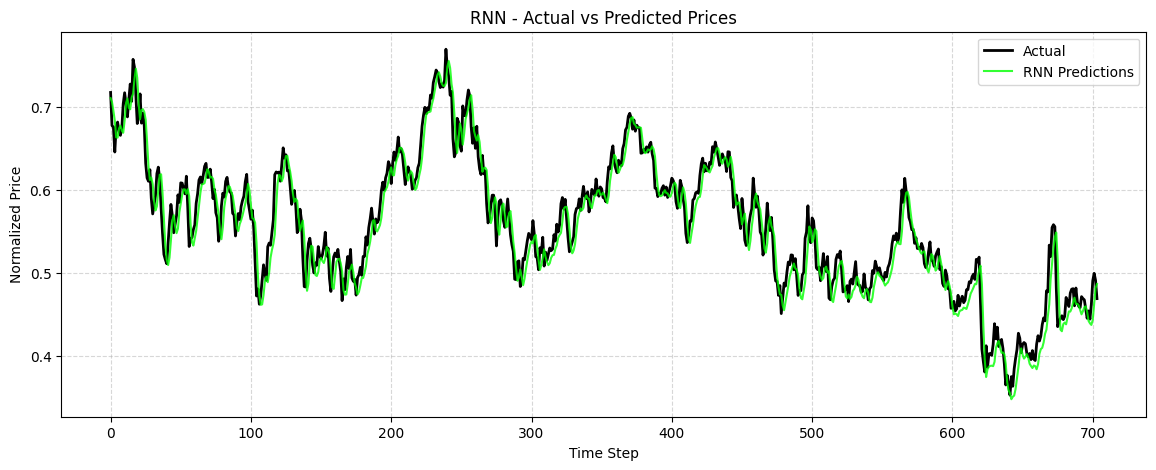

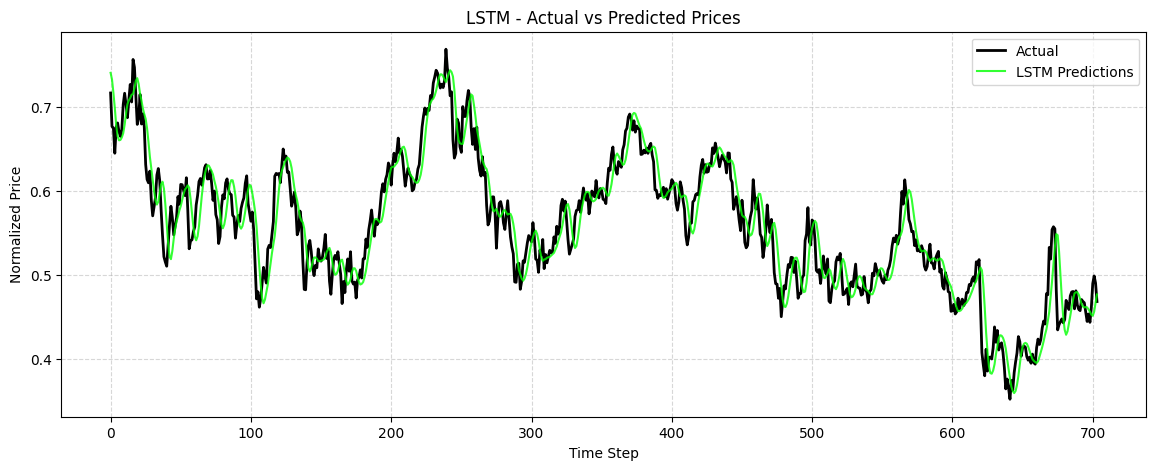

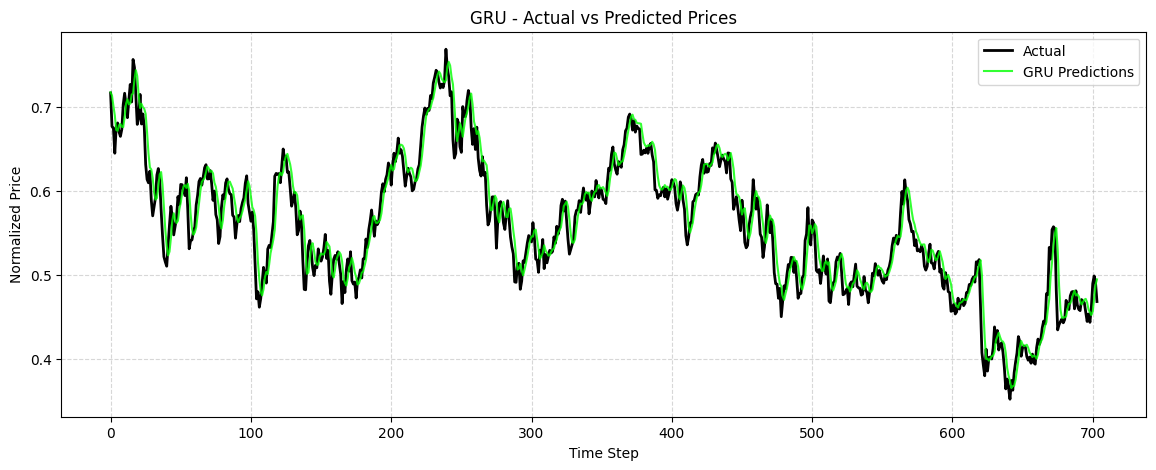

In [12]:
def plot_predictions(predictions, actual, model_name):
    plt.figure(figsize=(14,5))
    plt.plot(actual, label="Actual", color="black", linewidth=2)
    plt.plot(predictions, label=f"{model_name} Predictions", alpha=0.8,color='lime')
    plt.title(f"{model_name} - Actual vs Predicted Prices")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Price")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


# -------------------------------
# Run Predictions for all Models
# -------------------------------
models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

results = {}

for name, model in models.items():
    preds, actuals = predict(model, test_loader)
    results[name] = {"preds": preds, "actuals": actuals}
    plot_predictions(preds, actuals, name)


### 📊 3.2 Error Metrics
📌 Explain the following **error metrics** used in the paper:
- `RMSE` (Root Mean Square Error)
- `MAE` (Mean Absolute Error)
- `MAPE` (Mean Absolute Percentage Error)
- `R-Squared` (Coefficient of Determination)

**📌 Instruction:**  
Explain each of these error metrics and calculate them for **each model** (RNN, LSTM, GRU). Compare your results with the paper’s findings to see how closely they match.

🛠 *Your task:* Implement the evaluation metrics below. (15 Points)

In [13]:
# -------------------------------
# Metrics
# -------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def calculate_metrics(predictions, actual):
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mae = mean_absolute_error(actual, predictions)
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    r2 = r2_score(actual, predictions)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "R2": r2
    }

# Example usage with stored predictions
rnn_predictions = results["RNN"]["preds"]
lstm_predictions = results["LSTM"]["preds"]
gru_predictions = results["GRU"]["preds"]
actual_values   = results["RNN"]["actuals"]  # same actuals for all

print("📊 RNN Metrics:", calculate_metrics(rnn_predictions, actual_values))
print("📊 LSTM Metrics:", calculate_metrics(lstm_predictions, actual_values))
print("📊 GRU Metrics:", calculate_metrics(gru_predictions, actual_values))


📊 RNN Metrics: {'RMSE': 0.021998707, 'MAE': 0.017668748, 'MAPE (%)': 3.243052586913109, 'R2': 0.9225522636487805}
📊 LSTM Metrics: {'RMSE': 0.027589967, 'MAE': 0.02139957, 'MAPE (%)': 3.949921950697899, 'R2': 0.8781805347244638}
📊 GRU Metrics: {'RMSE': 0.022312257, 'MAE': 0.016981997, 'MAPE (%)': 3.1222647055983543, 'R2': 0.9203288061049627}


In [14]:
# Fill missing values for all features
data = yf.download("CL=F", start="2010-01-01")
data = data.reset_index()

filled_data = data.copy()
for column in ['Open', 'High', 'Low', 'Volume', 'Close']:
    filled_data[column] = filled_data[column].interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')

# WE WILL USE THESE IN ARIMA PART AS INPUTS OF MODELS
train_data = filled_data.iloc[:-int(0.3 * len(filled_data))]
test_data = filled_data.iloc[-int(0.3 * len(filled_data)):]
train_target = train_data['Close']
train_exog = train_data[['Open', 'High', 'Low', 'Volume']]
test_exog = test_data[['Open', 'High', 'Low', 'Volume']]

# ADF Test
from statsmodels.tsa.stattools import adfuller
result = adfuller(train_data['Close'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print(f"Critical Values: {result[4]}")
print("The series is stationary." if result[1] < 0.05 else "The series is not stationary.")

/tmp/ipykernel_134/3799431415.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("CL=F", start="2010-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_134/3799431415.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filled_data[column] = filled_data[column].interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
/tmp/ipykernel_134/3799431415.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filled_data[column] = filled_data[column].interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
/tmp/ipykernel_134/3799431415.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filled_data[

ADF Statistic: -1.5324516349280037
p-value: 0.5174012912935783
Critical Values: {'1%': -3.432718083748152, '5%': -2.862586250752157, '10%': -2.5673269523447004}
The series is not stationary.


# ARIMA Model Implementation

## 1️⃣ Difference between ARIMA and SARIMA Models

**ARIMA (AutoRegressive Integrated Moving Average):**
- Non-seasonal model for time series forecasting
- Parameters: (p, d, q) where:
  - p: order of autoregressive (AR) terms
  - d: degree of differencing
  - q: order of moving average (MA) terms

**SARIMA (Seasonal ARIMA):**
- Extends ARIMA to handle seasonal patterns
- Parameters: (p, d, q) × (P, D, Q, s) where:
  - (p, d, q): non-seasonal parameters
  - (P, D, Q): seasonal parameters
  - s: seasonal period (e.g., 12 for monthly data with yearly seasonality)

**Key Difference:** SARIMA incorporates seasonal components while ARIMA does not.

## 2️⃣ Advantages and Limitations of ARIMA

### Advantages:
- ✅ Simple and interpretable
- ✅ Handles non-stationary data through differencing
- ✅ Works well with univariate time series
- ✅ Provides probabilistic forecasts with confidence intervals
- ✅ Robust for short-term forecasting

### Limitations:
- ❌ Assumes linear relationships
- ❌ Requires stationary data (or differencing to achieve stationarity)
- ❌ Poor performance with irregular patterns or structural breaks
- ❌ Cannot handle exogenous variables in basic form
- ❌ Parameter selection can be challenging

## 3️⃣ Mathematical Formulation of ARIMA

ARIMA(p, d, q) model formulation:

**If d = 0 (stationary data):**
$$(1 - \phi_1B - \phi_2B^2 - \cdots - \phi_pB^p)Y_t = c + (1 + \theta_1B + \theta_2B^2 + \cdots + \theta_qB^q)\epsilon_t$$

**If d > 0 (differenced data):**
$$(1 - \phi_1B - \phi_2B^2 - \cdots - \phi_pB^p)(1 - B)^dY_t = c + (1 + \theta_1B + \theta_2B^2 + \cdots + \theta_qB^q)\epsilon_t$$

Where:
- $Y_t$: time series value at time t
- $B$: backshift operator ($BY_t = Y_{t-1}$)
- $\phi_i$: autoregressive parameters
- $\theta_i$: moving average parameters
- $\epsilon_t$: white noise error term
- $c$: constant term
- $d$: degree of differencing

## 4️⃣ Implementation: Finding Optimal ARIMA Parameters


📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)

🛠 *Your task:* Implement the ARIMA model below.

In [15]:
!pip install pmdarima


In [16]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Use training data (unscaled, original prices for ARIMA)
train_series = train_data["Close"].values

# Find optimal ARIMA order automatically
arima_model = auto_arima(
    train_series,
    seasonal=False,     # no seasonality for crude oil daily prices
    trace=True,         # print search process
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True       # faster search
)

print(f"Optimal ARIMA Order: {arima_model.order}")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=11376.454, Time=3.41 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11560.218, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11391.751, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11374.023, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=11558.307, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=11375.126, Time=0.61 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=11375.198, Time=0.31 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=11377.991, Time=0.57 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=11372.206, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=11373.317, Time=0.31 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=11373.388, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=11389.899, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=11375.263, Time=0.75 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 6.845 seconds
Optimal A

In [17]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from tqdm import tqdm
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=ConvergenceWarning, module="statsmodels")


train_series = train_data["Close"].values
test_series = test_data["Close"].values

# Fit ARIMA using optimal order from auto_arima
# If you already have arima_model.order, use that
p, d, q = arima_model.order

arima_fitted = ARIMA(train_series, order=(p,d,q)).fit()

# -------------------------------
# Rolling forecast
# -------------------------------
history_arima = list(train_series)
predictions = []

for t in tqdm(range(len(test_series))):
    model = ARIMA(history_arima, order=(p,d,q))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history_arima.append(test_series[t])  # add actual observation for next step

# Convert to numpy arrays
predictions = np.array(predictions)
actuals = np.array(test_series)




100%|██████████| 1187/1187 [02:08<00:00,  9.24it/s]


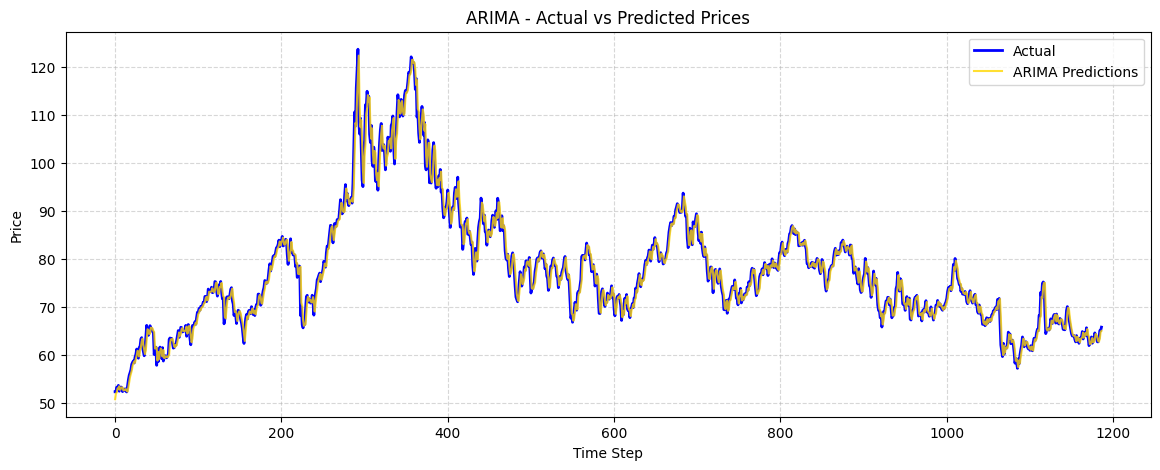

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(actuals, label="Actual", color="blue", linewidth=2)
plt.plot(predictions, label="ARIMA Predictions", alpha=0.8,color = 'gold')
plt.title("ARIMA - Actual vs Predicted Prices")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [19]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Example parameter combinations (you can expand if needed)
order_combinations = [(3,1,2)]
seasonal_combinations = [(3,1,1,12)]

# Initialize variables to store the best results
best_aic = float("inf")
best_order = None
best_seasonal_order = None
best_model = None

# Grid search over all parameter combinations
for order in order_combinations:
    for seasonal_order in seasonal_combinations:
        try:
            # Train SARIMA model
            model = SARIMAX(
                train_data["Close"],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            model_fit = model.fit(disp=False)

            # Check AIC
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = order
                best_seasonal_order = seasonal_order
                best_model = model_fit

        except Exception as e:
            print(f"Failed for order={order}, seasonal_order={seasonal_order}: {e}")
            continue

print(f"Best SARIMA Model: Order={best_order}, Seasonal_Order={best_seasonal_order}, AIC={best_aic}")
print(best_model.summary())


Best SARIMA Model: Order=(3, 1, 2), Seasonal_Order=(3, 1, 1, 12), AIC=11236.736037004397
                                      SARIMAX Results                                       
Dep. Variable:                                 CL=F   No. Observations:                 2771
Model:             SARIMAX(3, 1, 2)x(3, 1, [1], 12)   Log Likelihood               -5608.368
Date:                              Sun, 28 Sep 2025   AIC                          11236.736
Time:                                      02:43:08   BIC                          11295.816
Sample:                                           0   HQIC                         11258.094
                                             - 2771                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1    

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# kind of n steps to see and predict the next
history_sarima = list(train_series)[-50:]
sarima_predictions = []

# -------------------------------
# Rolling forecast (one-step ahead)
# -------------------------------
for t in tqdm(range(len(test_series))):
    # Re-fit SARIMA on the current history
    model = SARIMAX(
        history_sarima,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    model_fit = model.fit(disp=False)
    
    # Forecast the next step
    yhat = model_fit.forecast()[0]
    sarima_predictions.append(yhat)
    
    # Add the actual observed value to history for next iteration
    history_sarima.append(test_series[t])
    history_sarima = history_sarima[1:]

sarima_predictions = np.array(sarima_predictions)
actuals = np.array(test_series)



100%|██████████| 1187/1187 [03:06<00:00,  6.36it/s]


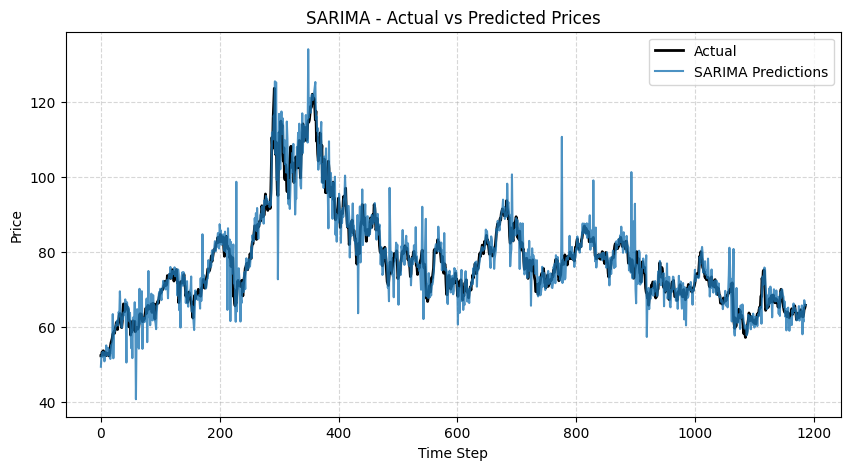

In [29]:
# -------------------------------
# Plot predictions vs actual
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(actuals, label="Actual", color="black", linewidth=2)
plt.plot(sarima_predictions, label="SARIMA Predictions", alpha=0.8)
plt.title("SARIMA - Actual vs Predicted Prices")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
